In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller

In [2]:
df = pd.read_csv("C:/Users/hp/OneDrive/Desktop/ML/maternalmortality.csv")
df.head()

,ISO3,Country,Continent,Hemisphere,Human Development Groups,UNDP Developeing Regions,HDI Rank (2021),"Maternal Mortality Ratio (deaths per 100,000 live births) (1990)","Maternal Mortality Ratio (deaths per 100,000 live births) (1991)","Maternal Mortality Ratio (deaths per 100,000 live births) (1992)",...,"Maternal Mortality Ratio (deaths per 100,000 live births) (2012)","Maternal Mortality Ratio (deaths per 100,000 live births) (2013)","Maternal Mortality Ratio (deaths per 100,000 live births) (2014)","Maternal Mortality Ratio (deaths per 100,000 live births) (2015)","Maternal Mortality Ratio (deaths per 100,000 live births) (2016)","Maternal Mortality Ratio (deaths per 100,000 live births) (2017)","Maternal Mortality Ratio (deaths per 100,000 live births) (2018)","Maternal Mortality Ratio (deaths per 100,000 live births) (2019)","Maternal Mortality Ratio (deaths per 100,000 live births) (2020)","Maternal Mortality Ratio (deaths per 100,000 live births) (2021)"
0,AFG,Afghanistan,Asia,Northern Hemisphere,Low,SA,180.0,1500.0,1530.0,1520.0,...,858.0,810.0,786.0,701.0,673.0,638.0,638.0,638.0,638.0,638.0
1,AGO,Angola,Africa,Southern Hemisphere,Medium,SSA,148.0,1150.0,1100.0,1130.0,...,281.0,269.0,258.0,251.0,246.0,241.0,241.0,241.0,241.0,241.0
2,ALB,Albania,Europe,Northern Hemisphere,High,ECA,67.0,40.0,47.0,49.0,...,17.0,16.0,16.0,15.0,16.0,15.0,15.0,15.0,15.0,15.0
3,AND,Andorra,Europe,Northern Hemisphere,Very High,NaN,40.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,ARE,United Arab Emirates,Asia,Northern Hemisphere,Very High,AS,26.0,13.0,12.0,11.0,...,4.0,3.0,3.0,3.0,3.0,3.0,3.0,3.0,3.0,3.0


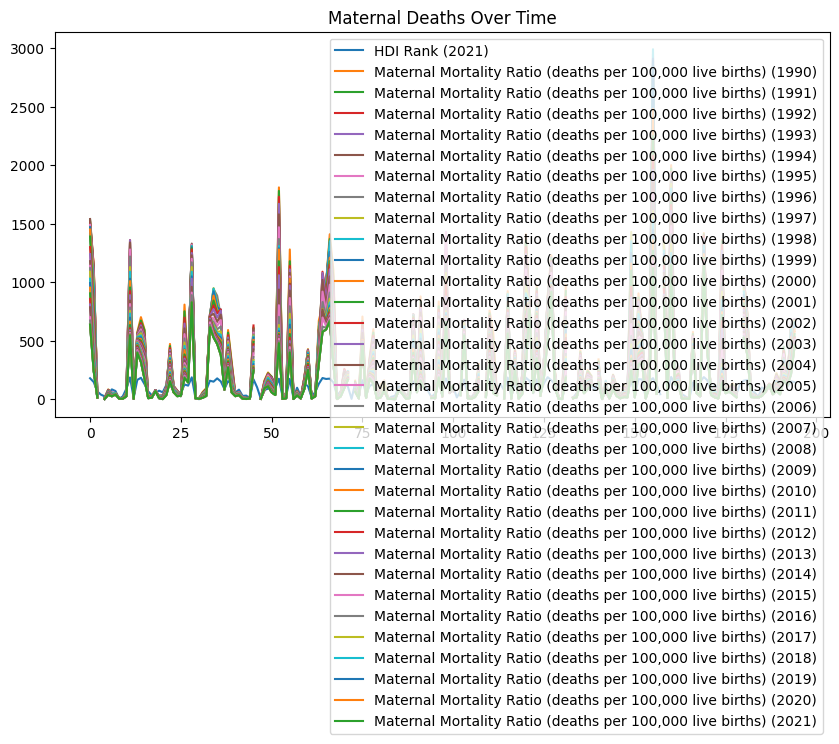

In [3]:
df.plot(figsize=(10,5))
plt.title("Maternal Deaths Over Time")
plt.show()

In [4]:
df_2012 = df[['Country', 'Maternal Mortality Ratio (deaths per 100,000 live births) (2012)']]
df_2012.sort_values(by=df_2012.columns[1], ascending=False).head()

,Country,"Maternal Mortality Ratio (deaths per 100,000 live births) (2012)"
155,Sierra Leone,1210.0
169,Chad,1190.0
160,South Sudan,1050.0
28,Central African Republic,963.0
127,Nigeria,963.0


In [8]:
kenya = df[df['Country'] == 'Kenya']

kenya_ts = kenya.iloc[:, 7:]  # picks year columns
kenya_ts = kenya_ts.T

kenya_ts.columns = ['value']
kenya_ts.index = kenya_ts.index.str.extract(r'(\d{4})')[0]
kenya_ts.index = pd.to_datetime(kenya_ts.index)

kenya_ts = kenya_ts.dropna()

In [9]:
from statsmodels.tsa.arima.model import ARIMA

model = ARIMA(kenya_ts, order=(1,1,1))
model_fit = model.fit()

forecast = model_fit.forecast(steps=5)
forecast

C:\Users\hp\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YS-JAN will be used.
  self._init_dates(dates, freq)
C:\Users\hp\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YS-JAN will be used.
  self._init_dates(dates, freq)
C:\Users\hp\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YS-JAN will be used.
  self._init_dates(dates, freq)


2022-01-01    341.978104
2023-01-01    341.957904
2024-01-01    341.939270
2025-01-01    341.922080
2026-01-01    341.906222
Freq: YS-JAN, Name: predicted_mean, dtype: float64

In [10]:
forecast.loc['2026']

2026-01-01    341.906222
Freq: YS-JAN, Name: predicted_mean, dtype: float64